# Rossmann Store Sales — Етап 3: Порівняння сегментів магазинів

Цей ноутбук реалізує **Етап 3** плану аналізу: порівняння груп магазинів за `StoreType`, `Assortment` та впливом конкуренції (`CompetitionDistance`), з перевіркою гіпотез Г3-Г5.

**Вхідний файл:** `rossmann_clean.csv` (результат Етапу 1)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


## 1. Завантаження даних

In [2]:
df = pd.read_csv("rossmann_clean.csv", parse_dates=["Date"], low_memory=False)
open_df = df[df["Open"] == 1].copy()
print(f"Відкритих днів для аналізу: {open_df.shape[0]:,}")
print(f"Унікальних магазинів: {open_df['Store'].nunique()}")


Відкритих днів для аналізу: 844,392
Унікальних магазинів: 1115


## 2. Розподіл магазинів за сегментами

Перед порівнянням продажів варто побачити, скільки взагалі магазинів у кожній групі — щоб розуміти, наскільки збалансовані вибірки.

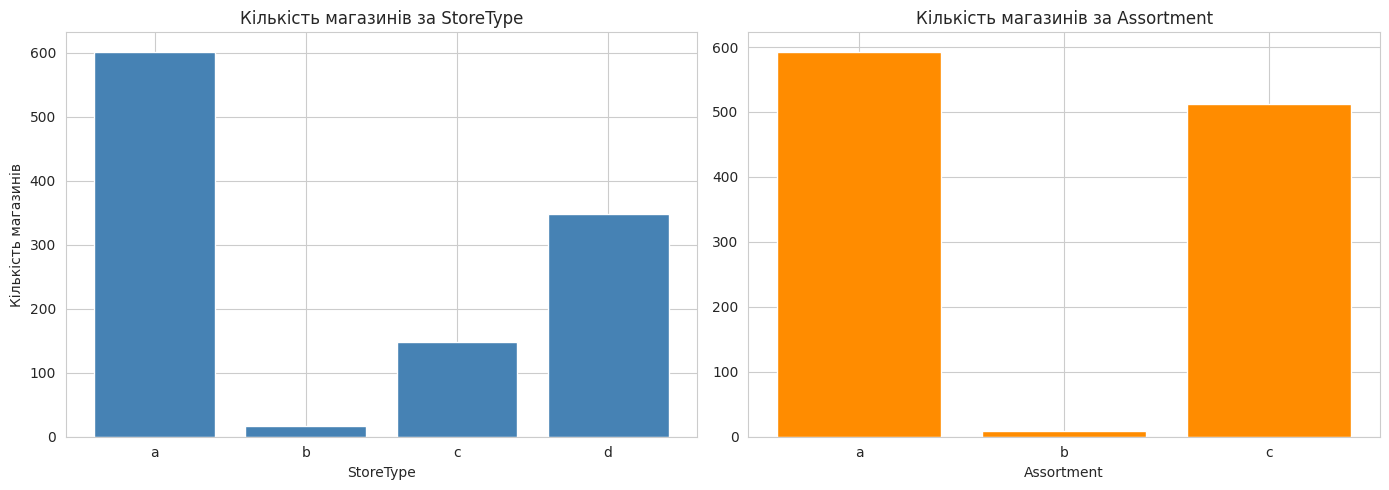

StoreType:
 StoreType
a    602
b     17
c    148
d    348
Name: count, dtype: int64

Assortment:
 Assortment
a    593
b      9
c    513
Name: count, dtype: int64


In [3]:
store_level = open_df.drop_duplicates(subset="Store")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

storetype_counts = store_level["StoreType"].value_counts().sort_index()
axes[0].bar(storetype_counts.index, storetype_counts.values, color="steelblue")
axes[0].set_title("Кількість магазинів за StoreType")
axes[0].set_xlabel("StoreType")
axes[0].set_ylabel("Кількість магазинів")

assortment_counts = store_level["Assortment"].value_counts().sort_index()
axes[1].bar(assortment_counts.index, assortment_counts.values, color="darkorange")
axes[1].set_title("Кількість магазинів за Assortment")
axes[1].set_xlabel("Assortment")

plt.tight_layout()
plt.savefig("03_segment_counts.png", dpi=150)
plt.show()

print("StoreType:\n", storetype_counts)
print("\nAssortment:\n", assortment_counts)


**Примітка:** якщо якийсь тип представлений дуже малою кількістю магазинів, порівняння середніх для нього буде менш надійним — це варто враховувати при інтерпретації.

## 3. Продажі за типом магазину (StoreType)

                   mean  median          std   count
StoreType                                           
b          10231.407505  9130.0  5157.190155   15563
c           6932.512755  6407.0  2897.564578  112978
a           6925.167661  6285.0  3277.786381  457077
d           6822.141881  6395.0  2556.582881  258774


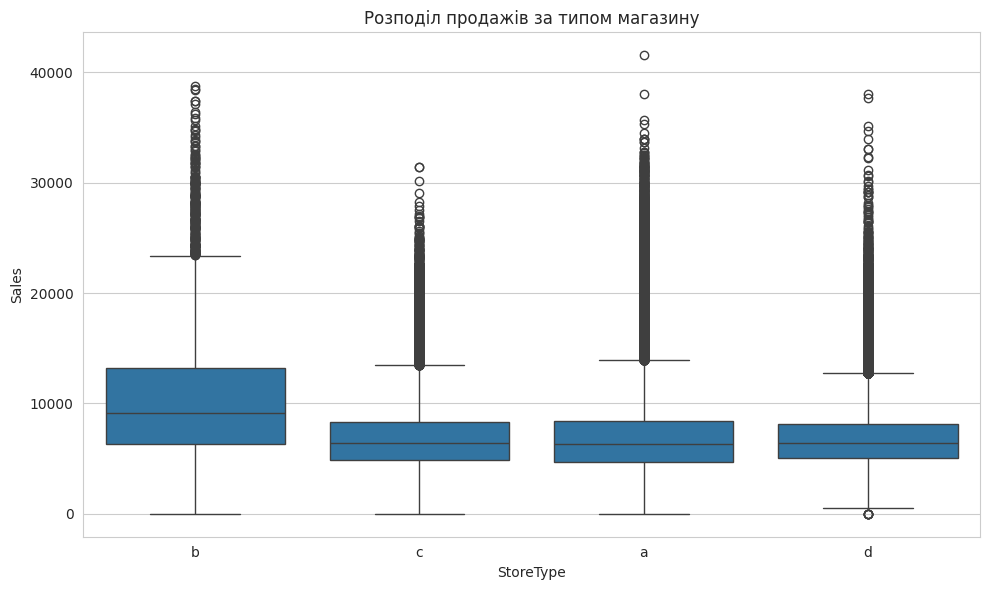

In [4]:
storetype_stats = open_df.groupby("StoreType")["Sales"].agg(["mean", "median", "std", "count"]).sort_values("mean", ascending=False)
print(storetype_stats)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=open_df, x="StoreType", y="Sales", order=storetype_stats.index, ax=ax)
ax.set_title("Розподіл продажів за типом магазину")
plt.tight_layout()
plt.savefig("03_boxplot_storetype.png", dpi=150)
plt.show()


**Важливе застереження щодо StoreType 'b':** цей тип представлений лише **17 магазинами** з 1115 (проти 602 для типу 'a'). Такий малий і незбалансований розмір вибірки означає, що високі середні продажі типу 'b' можуть відображати особливості кількох конкретних (можливо, великих флагманських) магазинів, а не загальну закономірність "тип b кращий". Tukey HSD нижче підтверджує статистичну значущість різниці, але **розмір вибірки не дозволяє впевнено узагальнювати цей висновок на "типовий магазин типу b"** — це радше сигнал дослідити ці 17 магазинів окремо, а не висновок для стратегії всієї мережі.

## 4. Продажі за типом асортименту (Assortment)

                   mean  median          std   count
Assortment                                          
b           8639.346322  8081.0  3806.006716    8212
c           7300.526339  6675.0  3184.144215  391271
a           6621.017039  6082.0  2972.500222  444909


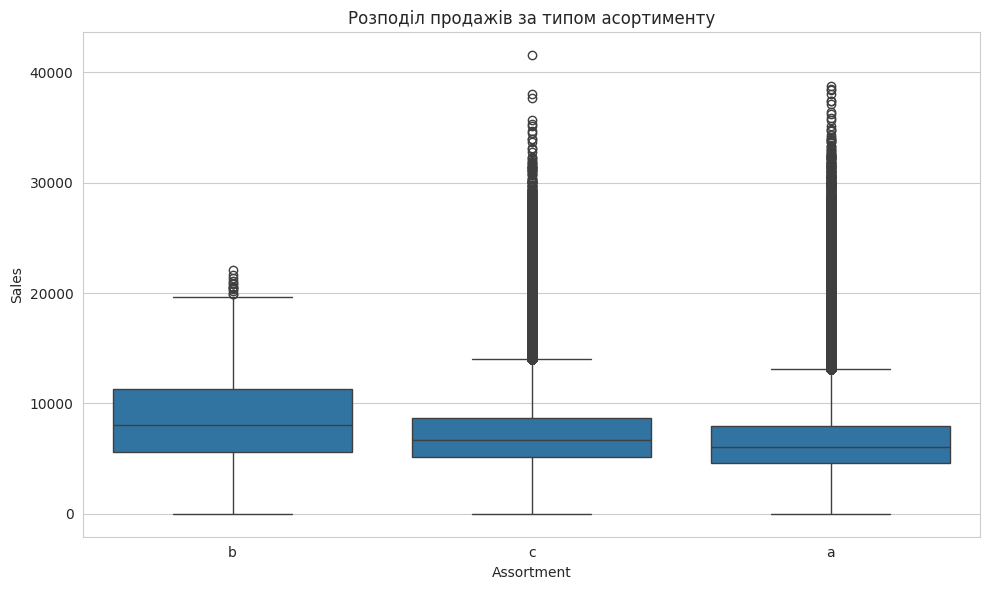

In [5]:
assortment_stats = open_df.groupby("Assortment")["Sales"].agg(["mean", "median", "std", "count"]).sort_values("mean", ascending=False)
print(assortment_stats)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=open_df, x="Assortment", y="Sales", order=assortment_stats.index, ax=ax)
ax.set_title("Розподіл продажів за типом асортименту")
plt.tight_layout()
plt.savefig("03_boxplot_assortment.png", dpi=150)
plt.show()


## 5. Взаємодія StoreType × Assortment

Чи однаково асортимент впливає на продажі всередині кожного типу магазину?

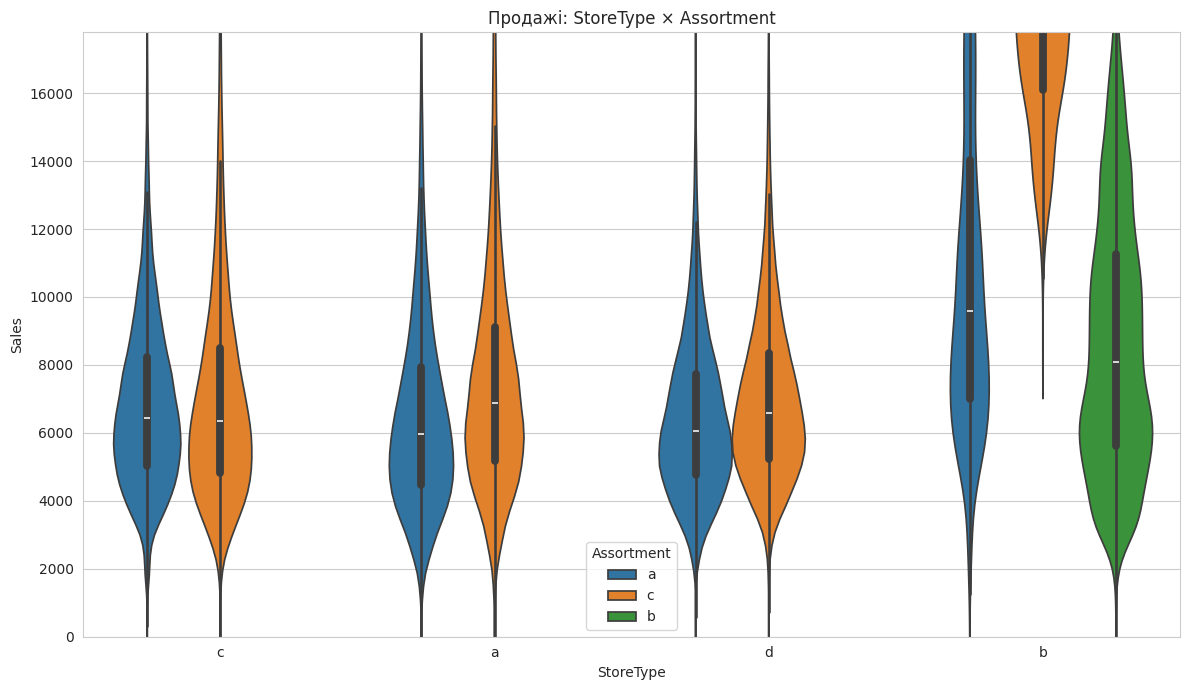

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(data=open_df, x="StoreType", y="Sales", hue="Assortment", split=False, ax=ax)
ax.set_title("Продажі: StoreType × Assortment")
ax.set_ylim(0, open_df["Sales"].quantile(0.99))  # обрізаємо для читабельності
plt.tight_layout()
plt.savefig("03_violin_storetype_assortment.png", dpi=150)
plt.show()


In [7]:
combo_stats = open_df.groupby(["StoreType", "Assortment"])["Sales"].agg(["mean", "count"]).reset_index()
combo_pivot = combo_stats.pivot(index="StoreType", columns="Assortment", values="mean")
print("Середні продажі (StoreType x Assortment):")
print(combo_pivot.round(0))

count_pivot = combo_stats.pivot(index="StoreType", columns="Assortment", values="count")
print("\nКількість спостережень у кожній комбінації:")
print(count_pivot)


Середні продажі (StoreType x Assortment):
Assortment        a       b        c
StoreType                           
a            6538.0     NaN   7573.0
b           11134.0  8639.0  17970.0
c            6835.0     NaN   7038.0
d            6434.0     NaN   7043.0

Кількість спостережень у кожній комбінації:
Assortment         a       b         c
StoreType                             
a           286053.0     NaN  171024.0
b             6409.0  8212.0     942.0
c            58561.0     NaN   54417.0
d            93886.0     NaN  164888.0


**Застереження щодо комбінацій StoreType × Assortment:** зверни увагу на таблицю кількості спостережень вище — комбінація StoreType='b' + Assortment='c' має лише 942 спостереження (і ймовірно, дуже мало унікальних магазинів), а StoreType='a'/'c'/'d' взагалі не мають Assortment='b' (NaN). Середнє 17970 для b+c — це найімовірніше 1-2 магазини, а не надійна статистика. Висновки про взаємодію StoreType × Assortment варто робити обережно, з явним зазначенням розміру вибірки.

**На що звернути увагу:** якщо в якійсь комбінації (наприклад, StoreType=b + Assortment=b) дуже мало спостережень, середнє для неї ненадійне — краще про це прямо написати у висновках, а не робити далекосяжні твердження.

## 6. Вплив відстані до конкурента (CompetitionDistance)

In [8]:
# Виключаємо рядки, де CompetitionDistance штучно заповнена (флаг _missing == 1) —
# інакше штучно велике значення спотворить кореляцію
comp_df = open_df[open_df["CompetitionDistance_missing"] == 0].copy()

# Середні продажі магазину vs відстань до конкурента (на рівні магазину, не дня)
store_agg = comp_df.groupby("Store").agg(
    avg_sales=("Sales", "mean"),
    competition_distance=("CompetitionDistance", "first"),
    store_type=("StoreType", "first")
).reset_index()

print(f"Магазинів у аналізі (з відомою відстанню до конкурента): {len(store_agg)}")
store_agg.head()


Магазинів у аналізі (з відомою відстанню до конкурента): 1112


,Store,avg_sales,competition_distance,store_type
0,1,4759.096031,1270.0,c
1,2,4953.900510,570.0,a
2,3,6942.568678,14130.0,a
3,4,9638.401786,620.0,c
4,5,4676.274711,29910.0,a


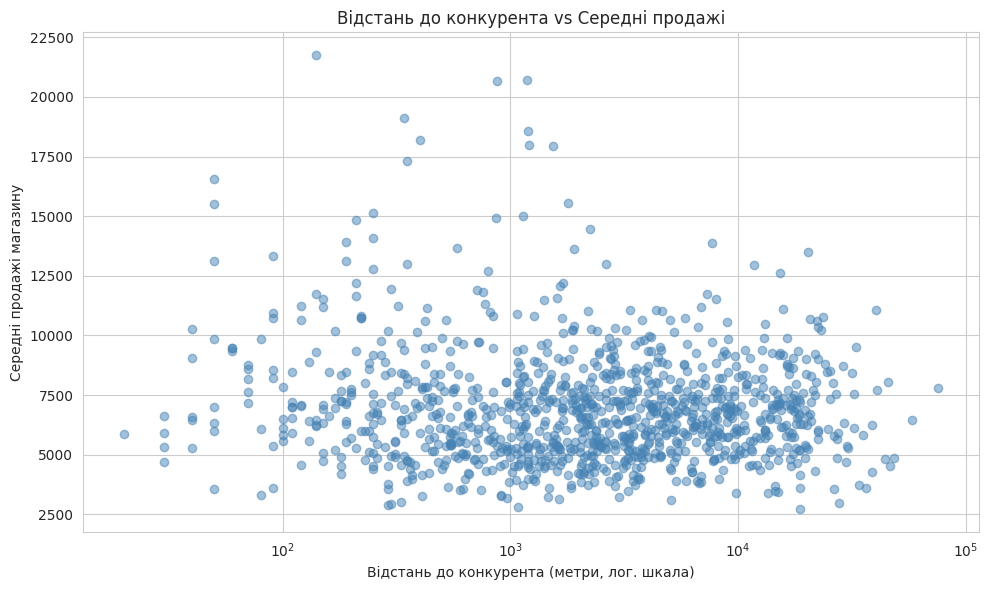

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(store_agg["competition_distance"], store_agg["avg_sales"], alpha=0.5, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Відстань до конкурента (метри, лог. шкала)")
ax.set_ylabel("Середні продажі магазину")
ax.set_title("Відстань до конкурента vs Середні продажі")
plt.tight_layout()
plt.savefig("03_scatter_competition_distance.png", dpi=150)
plt.show()


In [10]:
# Кореляція Пірсона (лінійна) і Спірмена (монотонна, стійкіша до викидів)
pearson_r, pearson_p = stats.pearsonr(store_agg["competition_distance"], store_agg["avg_sales"])
spearman_r, spearman_p = stats.spearmanr(store_agg["competition_distance"], store_agg["avg_sales"])

print(f"Кореляція Пірсона:  r={pearson_r:.4f}, p-value={pearson_p:.4f}")
print(f"Кореляція Спірмена: r={spearman_r:.4f}, p-value={spearman_p:.4f}")


Кореляція Пірсона:  r=-0.0424, p-value=0.1574
Кореляція Спірмена: r=-0.0280, p-value=0.3507


**Інтерпретація:** якщо кореляція близька до нуля (навіть при значущому p-value через великий розмір вибірки) — це означає, що зв'язок дуже слабкий практично, навіть якщо статистично "значущий". Важливо дивитись на знак і величину r, а не тільки на p-value.

## 7. Перевірка гіпотез

### Г3: Магазини типу `b` мають вищі середні продажі, ніж інші типи

In [11]:
# ANOVA: чи відрізняються середні продажі між StoreType
groups_storetype = [open_df[open_df["StoreType"] == t]["Sales"].values for t in open_df["StoreType"].unique()]
anova_stat, anova_p = stats.f_oneway(*groups_storetype)
print(f"ANOVA (StoreType): F={anova_stat:.2f}, p-value={anova_p:.2e}")
print("Висновок:", "є значуща різниця між типами" if anova_p < 0.05 else "значущої різниці немає")


ANOVA (StoreType): F=6081.82, p-value=0.00e+00
Висновок: є значуща різниця між типами


In [12]:
# Post-hoc Tukey HSD: які саме пари типів відрізняються
tukey_result = pairwise_tukeyhsd(endog=open_df["Sales"], groups=open_df["StoreType"], alpha=0.05)
print(tukey_result)


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
group1 group2  meandiff  p-adj    lower      upper    reject
------------------------------------------------------------
     a      b  3306.2398    0.0  3241.9261  3370.5536   True
     a      c     7.3451 0.8892   -18.8697    33.5599  False
     a      d  -103.0258    0.0  -122.4363   -83.6153   True
     b      c -3298.8948    0.0 -3366.3564 -3231.4331   True
     b      d -3409.2656    0.0 -3474.3857 -3344.1455   True
     c      d  -110.3709    0.0   -138.506   -82.2357   True
------------------------------------------------------------


In [13]:
print("Ранжування StoreType за середніми продажами:")
print(storetype_stats["mean"].sort_values(ascending=False))
top_type = storetype_stats["mean"].idxmax()
print(f"\nТип з найвищими середніми продажами: '{top_type}'")
print("Г3 (магазини типу 'b' мають найвищі продажі):",
      "ПІДТВЕРДЖЕНО статистично, АЛЕ" if top_type == "b" else f"НЕ підтверджено — найвищі продажі у типу '{top_type}'")
print("з важливим застереженням: лише 17 магазинів цього типу, тому висновок не можна впевнено")
print("узагальнювати на 'типовий магазин типу b' — дивись примітку вище про розмір вибірки.")


Ранжування StoreType за середніми продажами:
StoreType
b    10231.407505
c     6932.512755
a     6925.167661
d     6822.141881
Name: mean, dtype: float64

Тип з найвищими середніми продажами: 'b'
Г3 (магазини типу 'b' мають найвищі продажі): ПІДТВЕРДЖЕНО статистично, АЛЕ
з важливим застереженням: лише 17 магазинів цього типу, тому висновок не можна впевнено
узагальнювати на 'типовий магазин типу b' — дивись примітку вище про розмір вибірки.


### Г4: Магазини з повним асортиментом (`Assortment = c`) продають більше на клієнта, ніж базові (`Assortment = a`)

In [14]:
spc_by_assortment = open_df.groupby("Assortment")["SalesPerCustomer"].agg(["mean", "median", "count"])
print(spc_by_assortment)

# t-тест між Assortment a і c
group_a = open_df[open_df["Assortment"] == "a"]["SalesPerCustomer"]
group_c = open_df[open_df["Assortment"] == "c"]["SalesPerCustomer"]

if len(group_c) > 0:
    t_stat, t_p = stats.ttest_ind(group_a, group_c, equal_var=False)
    print(f"\nt-тест (Assortment a vs c) на SalesPerCustomer: t={t_stat:.2f}, p-value={t_p:.2e}")
    mean_diff = group_c.mean() - group_a.mean()
    print(f"Різниця середніх (c - a): {mean_diff:.2f}")
    print("Г4:", "ПІДТВЕРДЖЕНО" if (t_p < 0.05 and mean_diff > 0) else "НЕ підтверджено")
else:
    print("Немає магазинів з Assortment='c' у даних для порівняння")


                 mean    median   count
Assortment                             
a            9.130109  8.844444  444909
b            4.162205  4.079406    8212
c           10.017595  9.819246  391271



t-тест (Assortment a vs c) на SalesPerCustomer: t=-191.68, p-value=0.00e+00
Різниця середніх (c - a): 0.89
Г4: ПІДТВЕРДЖЕНО


### Г5: Близькість конкурента (менша CompetitionDistance) негативно корелює з продажами

In [15]:
print(f"Кореляція Спірмена (відстань до конкурента vs продажі): r={spearman_r:.4f}, p-value={spearman_p:.4f}")

if spearman_p < 0.05:
    direction = "позитивна (більша відстань -> вищі продажі)" if spearman_r > 0 else "негативна (більша відстань -> нижчі продажі)"
    print(f"Статистично значущий зв'язок є, напрямок: {direction}")
    print("Г5 (близькість конкурента негативно впливає, тобто менша відстань -> нижчі продажі):",
          "ПІДТВЕРДЖЕНО" if spearman_r > 0 else "НЕ підтверджено (зв'язок протилежний очікуваному)")
else:
    print("Статистично значущого зв'язку не знайдено — Г5 НЕ підтверджено")

print("\nВажливо: навіть якщо зв'язок статистично значущий, варто дивитись на величину r —")
print(f"|r| = {abs(spearman_r):.3f} " + ("(дуже слабкий зв'язок практично)" if abs(spearman_r) < 0.1 else "(помірний/сильний зв'язок)"))


Кореляція Спірмена (відстань до конкурента vs продажі): r=-0.0280, p-value=0.3507
Статистично значущого зв'язку не знайдено — Г5 НЕ підтверджено

Важливо: навіть якщо зв'язок статистично значущий, варто дивитись на величину r —
|r| = 0.028 (дуже слабкий зв'язок практично)


## Підсумок Етапу 3

- Магазини порівняно за `StoreType` і `Assortment` окремо та в комбінації
- Перевірено вплив відстані до конкурента через кореляцію Пірсона/Спірмена
- Г3 (StoreType 'b' найкращий), Г4 (Assortment 'c' вищий чек), Г5 (близькість конкурента шкодить продажам) — перевірено статистично, з post-hoc Tukey тестом для множинних порівнянь

**Наступний крок:** Етап 4 — формальний A/B-тест ефекту промо-акцій.